<a href="https://colab.research.google.com/github/KayotPoziloy/eeg_studies/blob/main/%D1%8D%D1%8D%D0%B35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Команда "Нейроштучки":** Гурская Юлия P3420, Яхонтов Максим P3420, Фархутдинов Айдар P3420.

Цель работы:
1. Собрать и подключиться установку для измерения лямбда-волн
2. Произвести следующие замеры по 5 минут каждый:
	1. Состояние покоя (глаза закрыты)
	2. Глаза открыты, концентрация на одной точке
	3. Игра в карты
	4. Просмотр рилс
	5. Поисковая игра
3. Сформулировать гипотезы
4. Обработать полученные данные
5. Построить графики и проанализировать
6. Сформулировать вывод

**ЭЭГ (электроэнцефалография)** — метод регистрации биоэлектрической активности мозга с помощью электродов, расположенных на коже головы.

### **Основные ритмы ЭЭГ**

**Delta (δ)**: 0.5–4 Гц, сон.

**Theta (θ)**: 4–8 Гц, расслабленность, дремота.

**Alpha (α)**: 8–13 Гц, состояние спокойного бодрствования, особенно при закрытых глазах.

**Beta (β)**: 13–30 Гц, активность, внимание, стресс.

**Gamma (γ)**: >30 Гц, когнитивные процессы.


### **Лямбда-ритмы**

Наиболее выражены в затылочной области (зрительная кора).

**Основные функции:**
1. Зрительный поиск - активация при сканировании зрительной сцены
2. Распознавание объектов - участие в идентификации
3. Концентрация внимания - усиление при целенаправленном зрительном внимании
4. Когнитивная обработка - участие в сложной зрительно-пространственной обработке

#### Усиливается при:

- Зрительном поиске (поиск объекта на сложном фоне)

- Сканировании изображений (рассмотрение деталей)

- Чтении (перемещение взгляда по тексту)

- Просмотре видео с активным зрительным вниманием

- Играх, требующих зрительно-моторной координации

#### Ослабляется/отсутствует при:

- Пассивном наблюдении без фокусировки внимания

- Сонливости или усталости

- Глаза закрыты (практически не регистрируется)

- Фиксации взгляда на одной точке без движения глаз

### Гипотезы

1. Покой (глаза закрыты): Амплитуда/мощность лямбда-ритма будет минимальной из-за отсутствия зрительного ввода.

2. Фиксация на точке: Лямбда-активность будет выше, чем в покое, но относительно низкой из-за отсутствия движения глаз.

3. Игра в "Дурак": Сильный всплеск лямбда-ритма из-за необходимости отслеживания карт, планирования ходов и сканирования игрового поля.

4. Просмотр Reels: Высокая активность, но, возможно, менее устойчивая, чем в игре, из-за пассивного потребления и быстрой смены кадров.

5. Поисковая игра: Максимальная мощность лямбда-ритма из-за активного сканирования, поиска целей и постоянных саккад.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, hilbert, freqz

# **Предобработка данных**

In [ ]:
file_paths = [
    "/content/drive/MyDrive/ээг/лаб5/1_12_2025_12_49_21_EEG.dat",
    "/content/drive/MyDrive/ээг/лаб5/1_12_2025_13_12_36_EEG.dat",
    "/content/drive/MyDrive/ээг/лаб5/1_12_2025_13_3_4_EEG.dat",
    "/content/drive/MyDrive/ээг/лаб5/1_12_2025_13_53_18_EEG.dat",
    "/content/drive/MyDrive/ээг/лаб5/1_12_2025_14_1_42_EEG.dat"
]

# Считываем данные
# Создаем словарь для хранения данных
dataframes = {}

# Функция для проверки файла с разными разделителями
def get_data(file_path):
    try:
        # Сначала попробуем определить разделитель
        with open(file_path, 'r') as f:
            first_lines = [f.readline() for _ in range(5)]

        # Анализируем возможные разделители
        possible_delimiters = [';', ',', '\t', ' ']

        for delimiter in possible_delimiters:
            try:
                df = pd.read_csv(file_path, sep=delimiter, engine='python')
                # Проверяем, что DataFrame имеет данные
                if not df.empty and len(df.columns) >= 2:
                    print(f"Файл {file_path.split('/')[-1]}: использован разделитель '{delimiter}'")
                    print(f"  Столбцы: {list(df.columns)}")
                    print(f"  Размер: {df.shape}")
                    return df
            except:
                continue

        # Если ни один разделитель не подошел, попробуем без указания разделителя
        df = pd.read_csv(file_path, engine='python')
        print(f"Файл {file_path.split('/')[-1]}: использовано автоопределение разделителя")
        print(f"  Столбцы: {list(df.columns)}")
        print(f"  Размер: {df.shape}")
        return df

    except Exception as e:
        print(f"Ошибка при загрузке файла {file_path}: {e}")
        return None

# Загружаем все файлы
print("ЗАГРУЗКА ФАЙЛОВ:")
for i, path in enumerate(file_paths, 1):
    df = get_data(path)
    if df is not None:
        dataframes[path] = df
        print(f"✓ Файл {i}/{len(file_paths)} загружен: {path.split('/')[-1]}")
    else:
        print(f"✗ Файл {i}/{len(file_paths)} не загружен: {path.split('/')[-1]}")
    print()

# Пример доступа к данным
if len(dataframes) > 0:
    first_key = list(dataframes.keys())[0]
    print(f"ПРИМЕР ДАННЫХ из первого файла ({first_key.split('/')[-1]}):")
    print(dataframes[first_key].head())
    print(f"\nТипы данных:")
    print(dataframes[first_key].dtypes)
else:
    print("Нет загруженных данных!")
    exit()

# Создаем словарь для проверки пропусков в данных
missing_info = {}

# Функция для проверки файла
def check_file_for_missing(df):
    total_missing = df.isnull().sum().sum()
    missing_per_column = df.isnull().sum()
    return total_missing, missing_per_column

# Проверяем все файлы
print("ПРОВЕРКА ПРОПУСКОВ В ДАННЫХ:")

for i, (path, df) in enumerate(dataframes.items(), 1):
    total_missing, missing_per_col = check_file_for_missing(df)
    missing_info[path] = {
        'total_missing': total_missing,
        'missing_per_column': missing_per_col,
        'shape': df.shape,
        'columns': df.columns.tolist()
    }

    print(f"\nФайл {i}: {path.split('/')[-1]}")
    print(f"  Размер данных: {df.shape}")
    print(f"  Столбцы: {list(df.columns)}")
    print(f"  Всего пропущенных значений: {total_missing}")

    if total_missing > 0:
        print("  Пропуски по столбцам:")
        for col, missing_count in missing_per_col.items():
            if missing_count > 0:
                print(f"    - {col}: {missing_count} пропусков")
    else:
        print(" Пропусков нет!")

# Переименовываем столбцы во всех датафреймах
print("ПЕРЕИМЕНОВАНИЕ СТОЛБЦОВ:")

for path, df in dataframes.items():
    filename = path.split('/')[-1]

    # Проверяем количество столбцов
    if len(df.columns) >= 2:
        # Сохраняем оригинальные названия для информации
        original_columns = df.columns.tolist()

        # Создаем новые названия
        if len(df.columns) == 2:
            new_columns = ['time', 'voltage']
        else:
            new_columns = ['time', 'voltage'] + [f'channel_{i+1}' for i in range(len(df.columns)-2)]

        # Переименовываем
        df.columns = new_columns
        print(f" {filename}: переименовано {len(df.columns)} столбцов")
        print(f"  Было: {original_columns}")
        print(f"  Стало: {new_columns}")
    else:
        print(f"✗ {filename}: только {len(df.columns)} столбцов, нужно минимум 2")

# Для каждого датафрейма устанавливаем первую точку времени как 0
print("НОРМАЛИЗАЦИЯ ВРЕМЕНИ:")

for path, df in dataframes.items():
    filename = path.split('/')[-1]

    if 'time' in df.columns and len(df) > 0:
        # Находим первое значение времени
        first_time = df['time'].iloc[0]

        # Проверяем тип данных времени
        print(f"\n{filename}:")
        print(f"  Первое значение времени: {first_time}")
        print(f"  Тип данных времени: {df['time'].dtype}")

        # Вычитаем его из всего столбца времени
        df['time'] = (df['time'] - first_time)

        print(f"  Нормализовано: время начинается с 0")
        print(f"  Последнее значение: {df['time'].iloc[-1]:.2f}")
    else:
        print(f"\n✗ {filename}: столбец 'time' не найден")

# Проверим результат на примере первого файла
if len(dataframes) > 0:
    first_key = list(dataframes.keys())[0]
    df1 = dataframes[first_key]

    print(f"ПРОВЕРКА НОРМАЛИЗАЦИИ для первого файла ({first_key.split('/')[-1]}):")

    # Проверяем существование столбца time
    if 'time' in df1.columns:
        print("\nВремя после нормализации (первая точка = 0):")
        print(df1['time'].head(10))

        # Дополнительная информация
        print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
        print(f"Длина временного ряда: {len(df1)}")
        print(f"Общая длительность: {df1['time'].iloc[-1]:.2f} сек")

        if df1['time'].iloc[-1] > 0:
            print(f"Частота дискретизации (приблизительно): {len(df1)/df1['time'].iloc[-1]:.1f} Гц")

        # Вывод информации о напряжении
        if 'voltage' in df1.columns:
            print(f"\nСТАТИСТИКА ПО НАПРЯЖЕНИЮ:")
            print(f"Минимум: {df1['voltage'].min():.4f}")
            print(f"Максимум: {df1['voltage'].max():.4f}")
            print(f"Среднее: {df1['voltage'].mean():.4f}")
            print(f"Стандартное отклонение: {df1['voltage'].std():.4f}")

            # Проверяем наличие выбросов
            voltage_data = df1['voltage'].values
            q1 = np.percentile(voltage_data, 25)
            q3 = np.percentile(voltage_data, 75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            outliers = np.sum((voltage_data < lower_bound) | (voltage_data > upper_bound))
            if outliers > 0:
                print(f"Возможные выбросы: {outliers} значений ({outliers/len(voltage_data)*100:.1f}%)")
            else:
                print(f"Выбросы: не обнаружены")
    else:
        print(f"✗ Столбец 'time' не найден в файле!")
        print(f"Доступные столбцы: {list(df1.columns)}")
else:
    print("Нет загруженных данныхфреймов!")

# Выводим сводную информацию по всем файлам
print("СВОДНАЯ ИНФОРМАЦИЯ ПО ВСЕМ ФАЙЛАМ:")

for i, (path, df) in enumerate(dataframes.items(), 1):
    filename = path.split('/')[-1]
    print(f"\n{i}. {filename}:")
    print(f"   Размер: {df.shape}")

    if 'time' in df.columns and 'voltage' in df.columns:
        duration = df['time'].iloc[-1] if len(df) > 0 else 0
        print(f"   Длительность: {duration:.2f} сек")
        print(f"   Частота (приблиз.): {len(df)/duration:.1f} Гц" if duration > 0 else "   Частота: N/A")
        print(f"   Напряжение: от {df['voltage'].min():.4f} до {df['voltage'].max():.4f}")
    else:
        print(f"   Доступные столбцы: {list(df.columns)}")

ЗАГРУЗКА ФАЙЛОВ:
Файл 1_12_2025_12_49_21_EEG.dat: использован разделитель '	'
  Столбцы: ['3.39079976', '2.25490189']
  Размер: (97288, 2)
✓ Файл 1/5 загружен: 1_12_2025_12_49_21_EEG.dat

Файл 1_12_2025_13_12_36_EEG.dat: использован разделитель '	'
  Столбцы: ['586.28546143', '2.60784316']
  Размер: (97187, 2)
✓ Файл 2/5 загружен: 1_12_2025_13_12_36_EEG.dat

Файл 1_12_2025_13_3_4_EEG.dat: использован разделитель '	'
  Столбцы: ['14.64759064', '1.62745094']
  Размер: (126831, 2)
✓ Файл 3/5 загружен: 1_12_2025_13_3_4_EEG.dat

Файл 1_12_2025_13_53_18_EEG.dat: использован разделитель '	'
  Столбцы: ['387.05322266', '2.96078420']
  Размер: (99561, 2)
✓ Файл 4/5 загружен: 1_12_2025_13_53_18_EEG.dat

Файл 1_12_2025_14_1_42_EEG.dat: использован разделитель '	'
  Столбцы: ['891.28167725', '2.37254906']
  Размер: (100480, 2)
✓ Файл 5/5 загружен: 1_12_2025_14_1_42_EEG.dat

ПРИМЕР ДАННЫХ из первого файла (1_12_2025_12_49_21_EEG.dat):
   3.39079976  2.25490189
0    3.390800    2.176471
1    3.39487

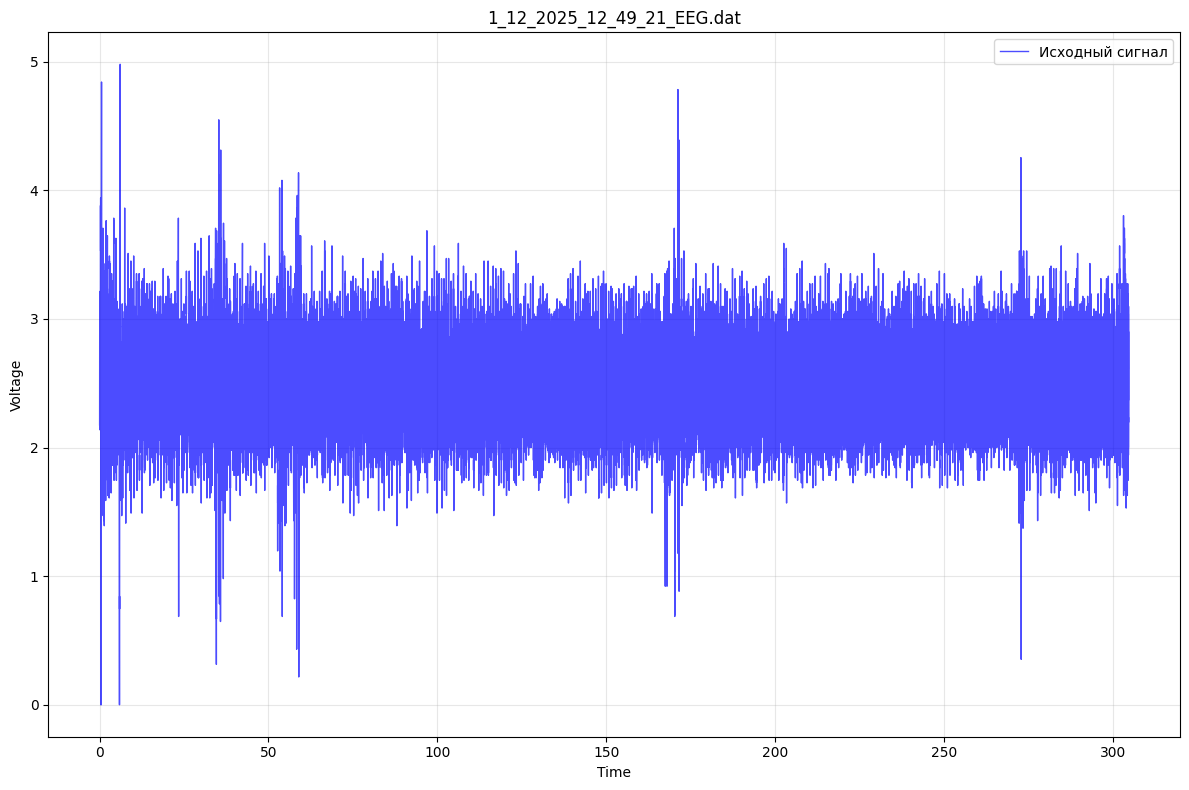

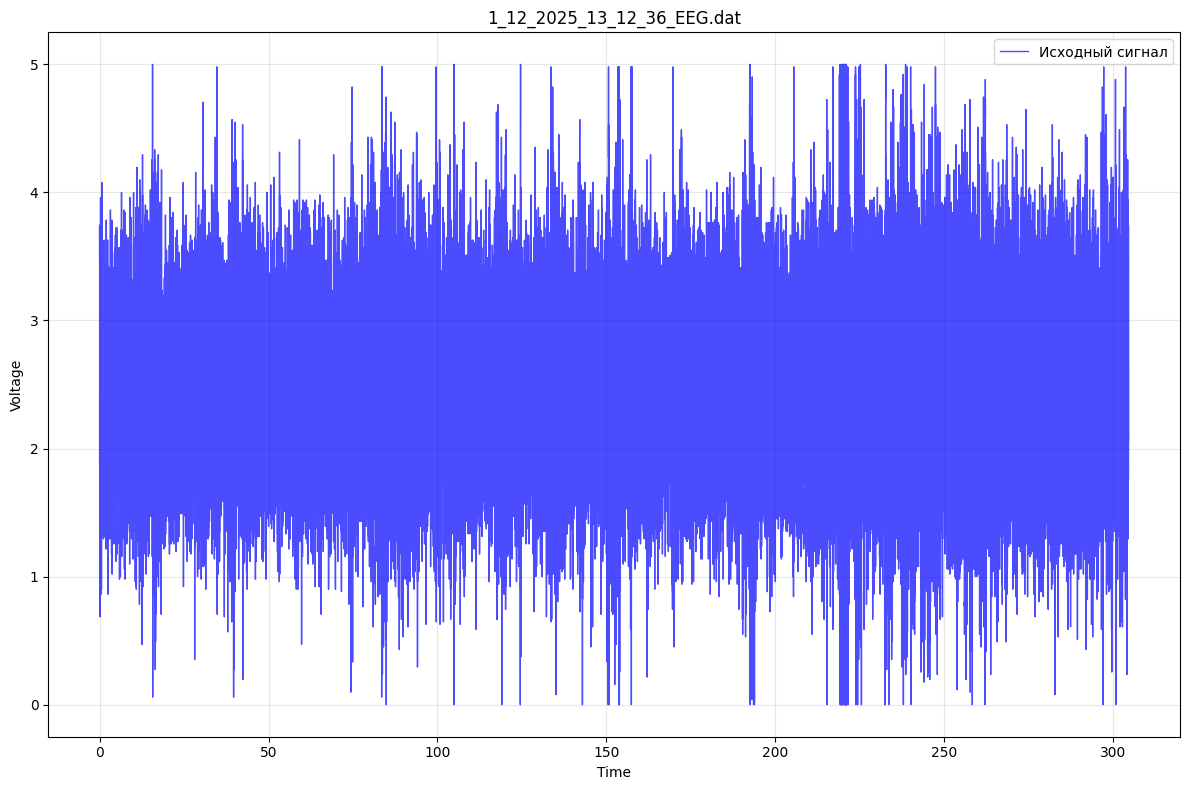

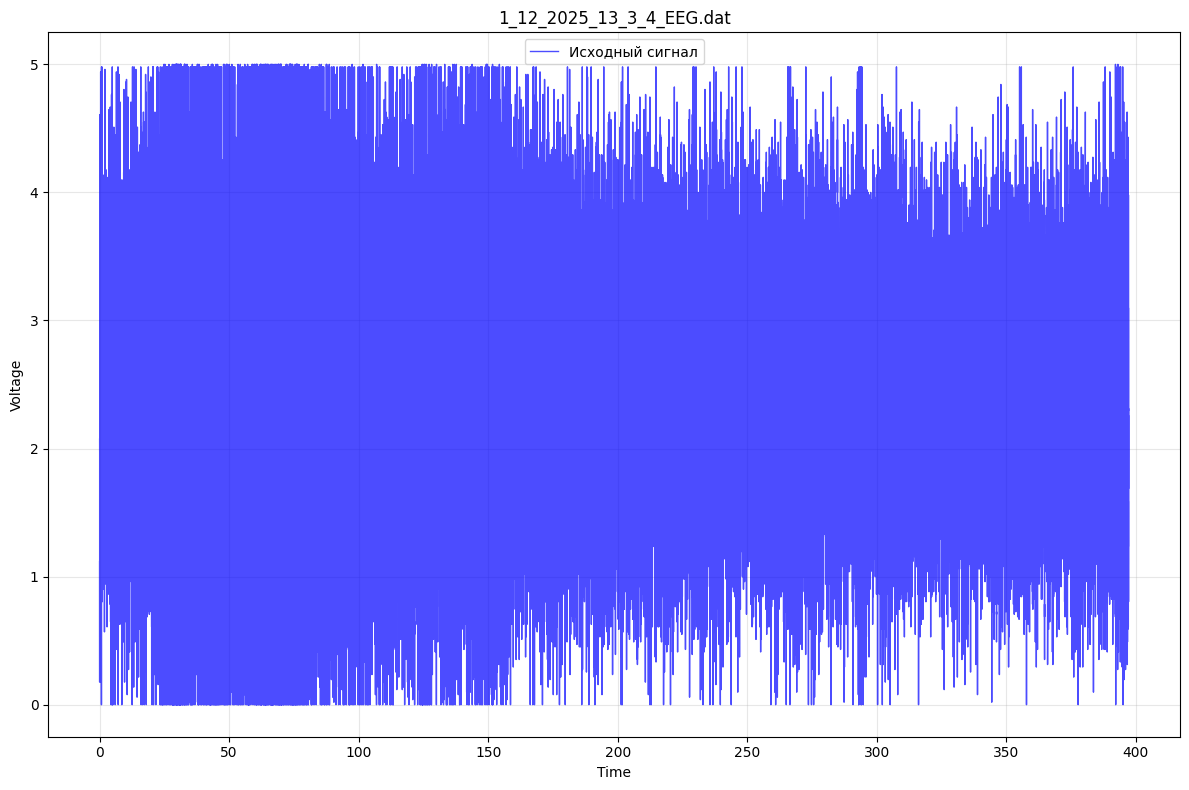

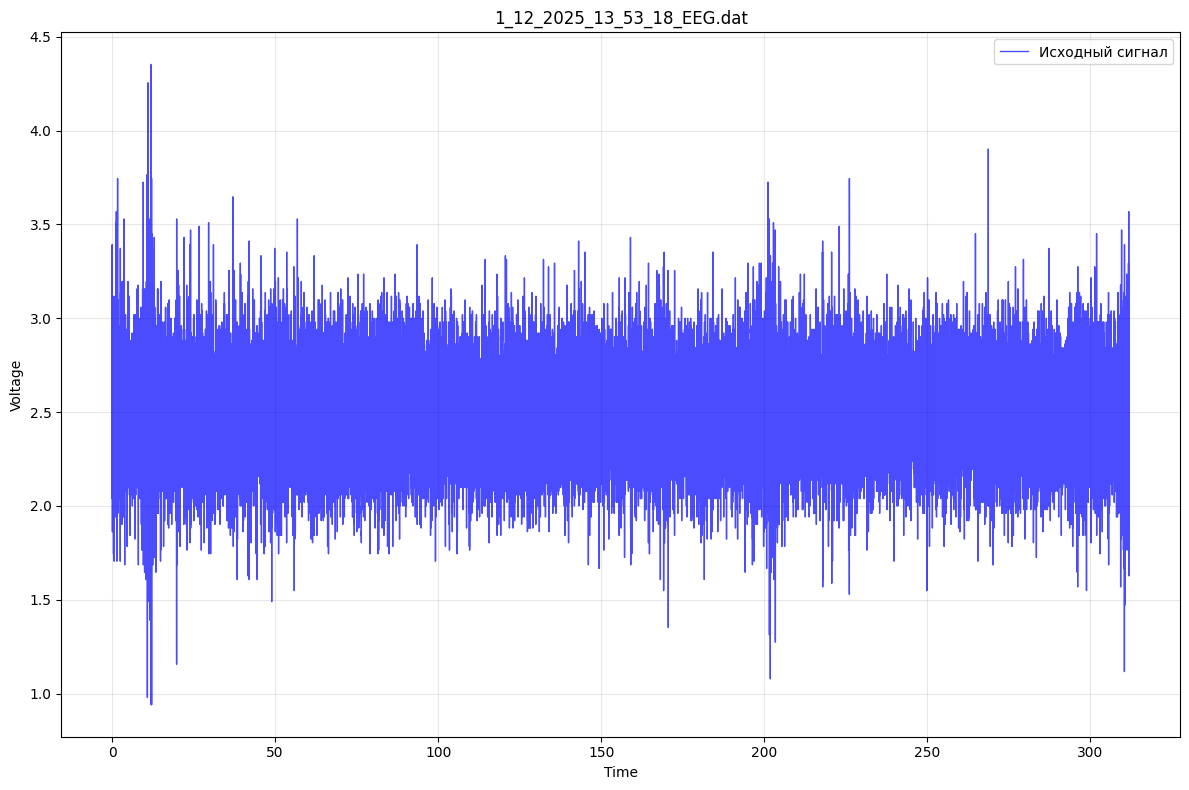

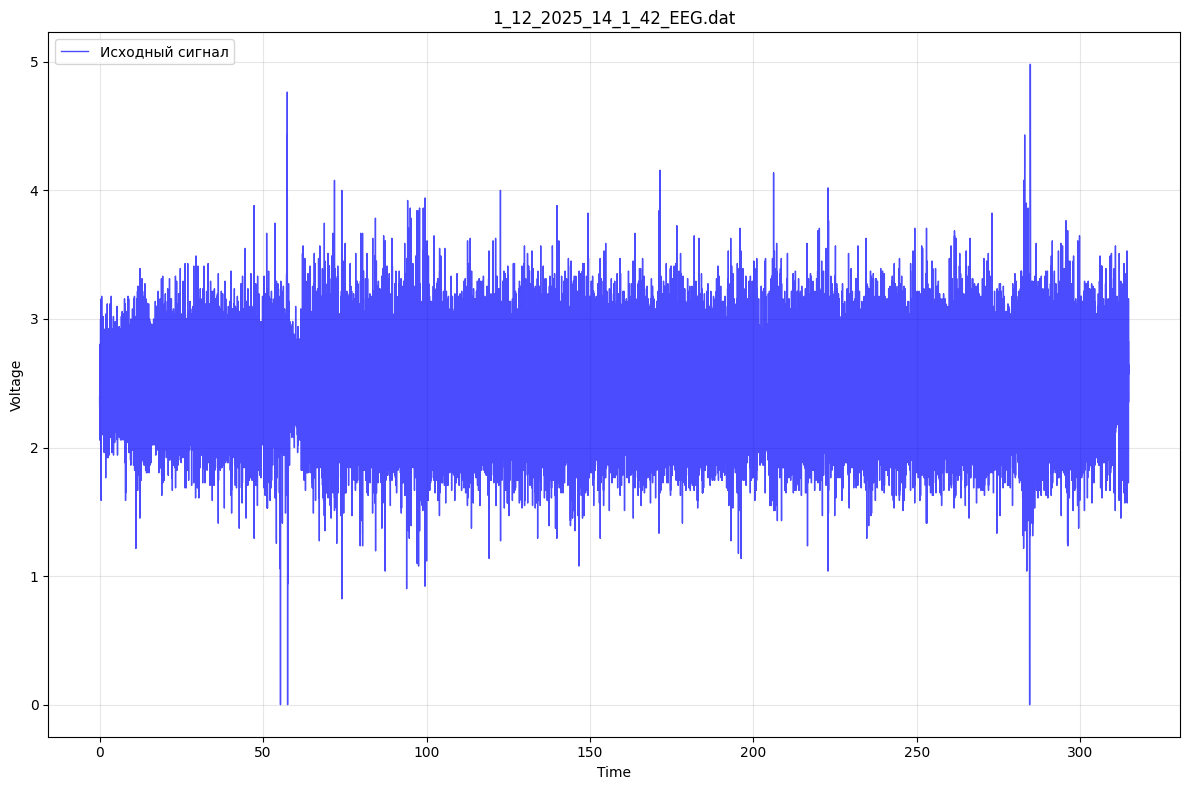

In [ ]:
# Визуализация исходных данных (с учетом проверки пропусков, подписания столбцов)
for path, df in dataframes.items():
    filename = path.split('/')[-1]
    if 'voltage' not in df.columns:
        print(f"В файле {filename} нет столбца voltage")
        continue

    plt.figure(figsize=(12, 8))
    plt.plot(df['time'], df['voltage'], 'blue', alpha=0.7, label='Исходный сигнал', linewidth=1)
    plt.title(f'{filename}')
    plt.xlabel('Time')
    plt.ylabel('Voltage')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Построим график для 10-секундного фрагмента каждой записи

Длительность записи: 304.68387675 секунд
Середина: 152.341938375 секунд


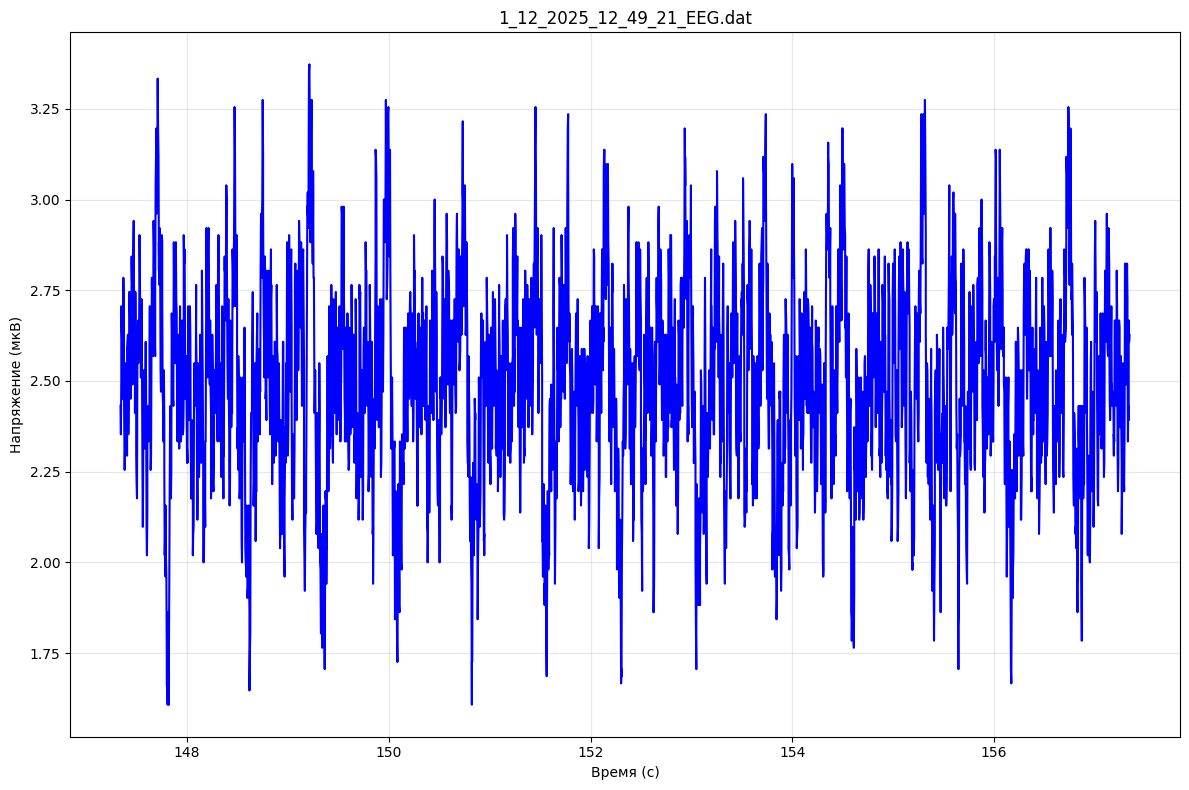

Длительность записи: 304.53631592 секунд
Середина: 152.26815796 секунд


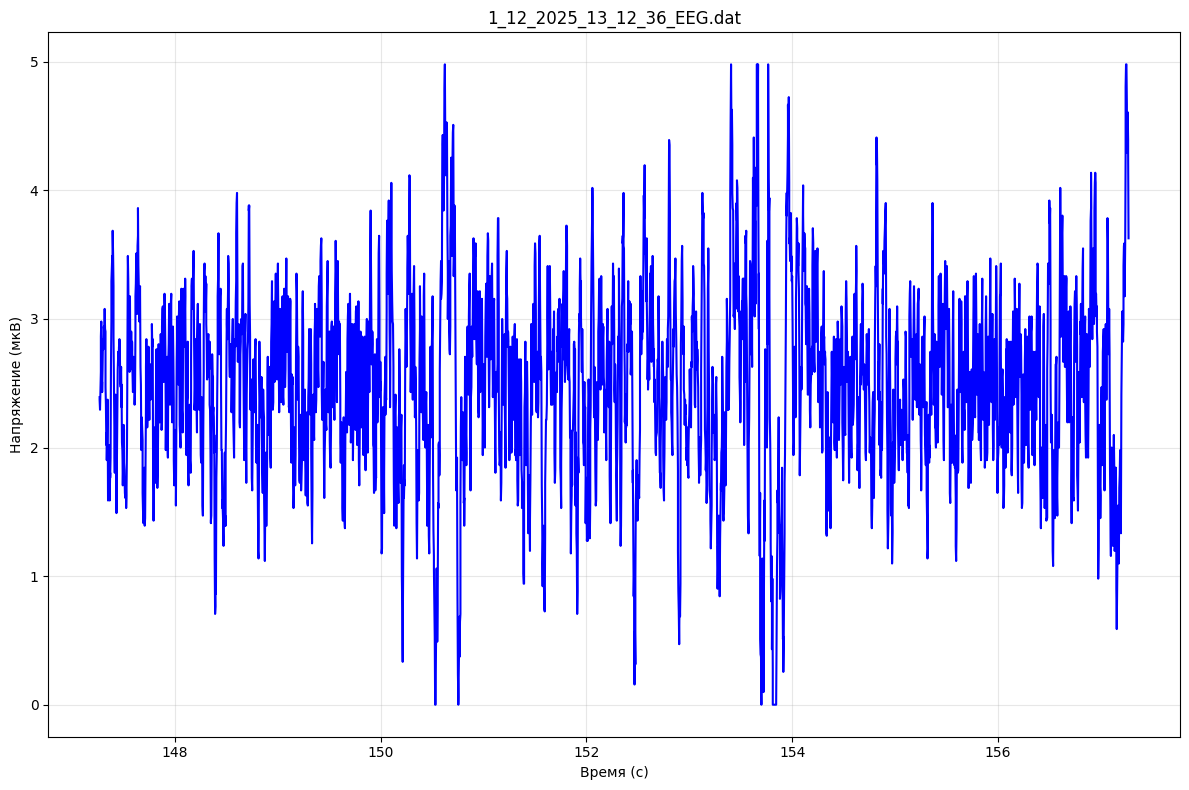

Длительность записи: 397.23808575 секунд
Середина: 198.619042875 секунд


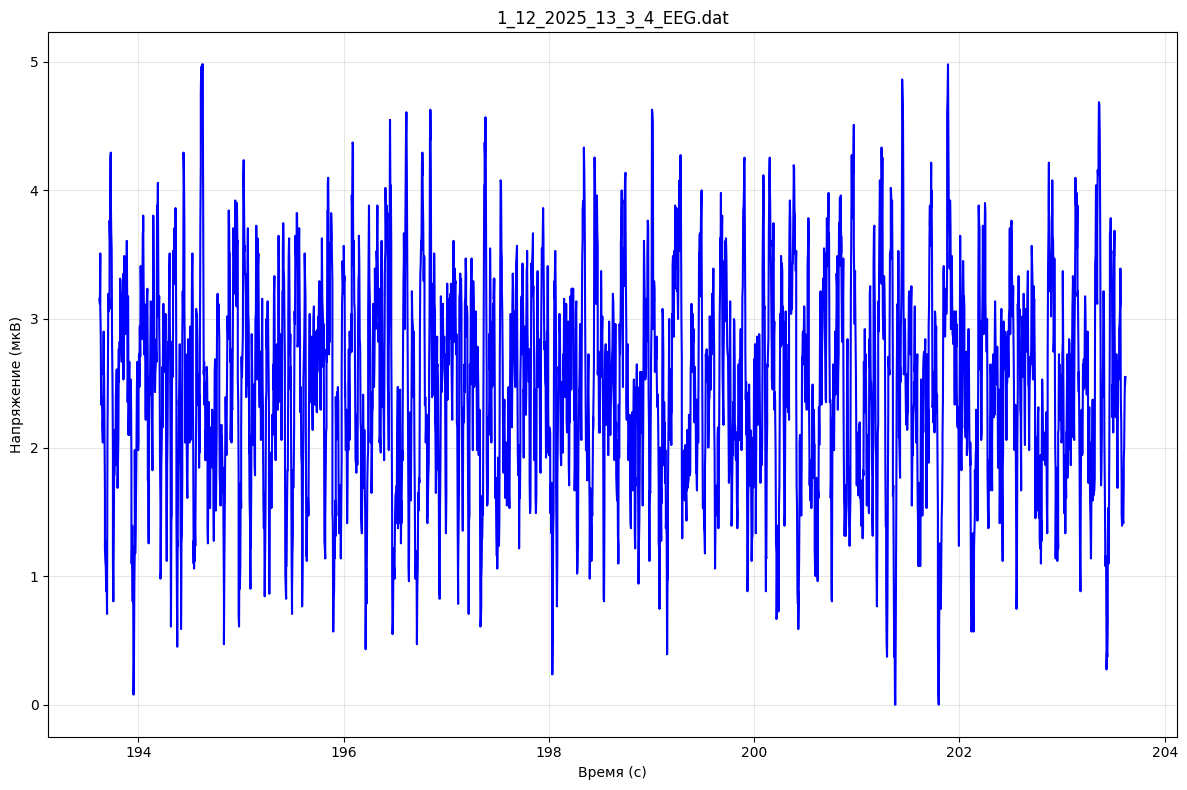

Длительность записи: 311.86505127000004 секунд
Середина: 155.93252563500002 секунд


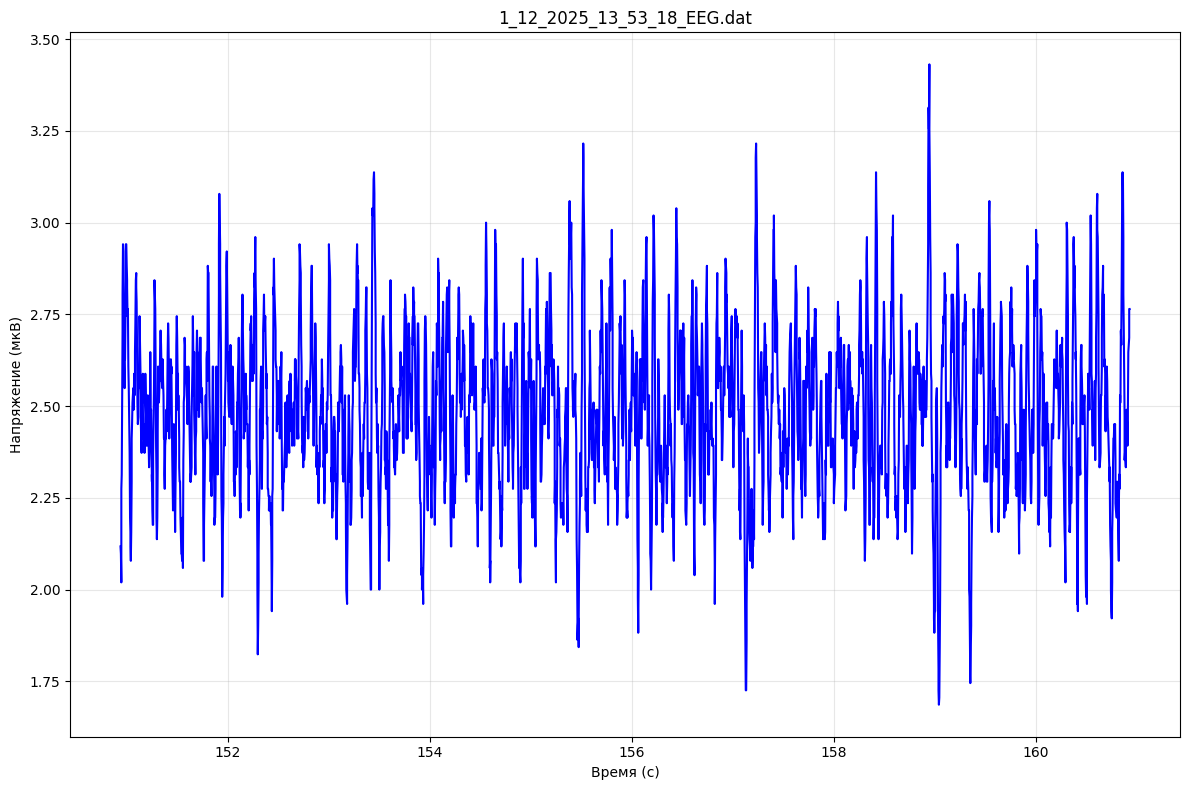

Длительность записи: 314.73248290999993 секунд
Середина: 157.36624145499997 секунд


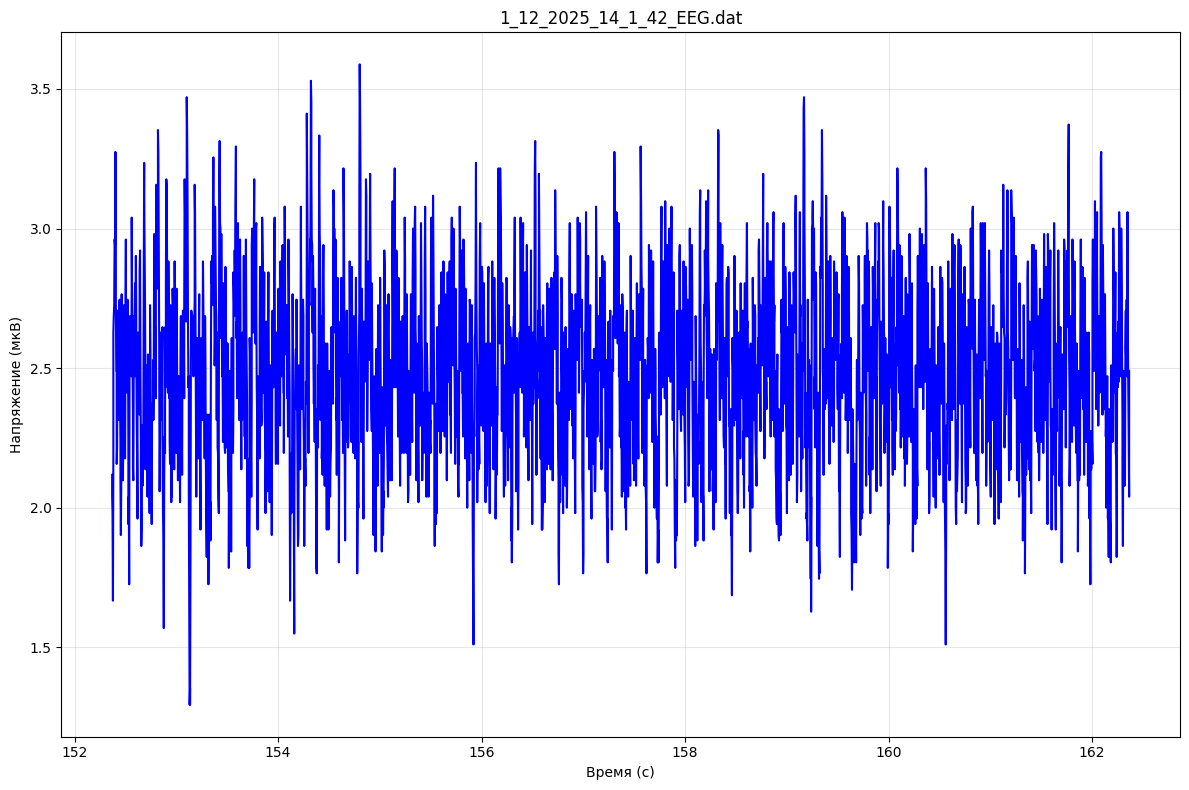

In [ ]:
for path, df in dataframes.items():
  filename = path.split('/')[-1]

  # Общая длительность записи
  total_time = df['time'].iloc[-1]
  print("Длительность записи:", total_time, "секунд")

  # Время середины
  mid_time = total_time / 2
  print("Середина:", mid_time, "секунд")

  # Берем 10 секунд вокруг середины
  start = mid_time - 5
  end = mid_time + 5
  fragment = df[(df['time'] >= start) & (df['time'] <= end)]

  plt.figure(figsize=(12, 8))
  plt.plot(fragment['time'], fragment['voltage'], color='blue')
  plt.title(f'{filename}')
  plt.xlabel("Время (с)")
  plt.ylabel("Напряжение (мкВ)")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()



### Фильтрация

1. Полосовой фильтр 4-8 ГЦ

2. Фильтр Баттерворта - обеспечивает максимально плоскую амплитудную характеристику в полосе пропускания

In [ ]:
# Определяем частоту дискретизации для каждого эксперимента
fs_dict = {}
experiment_names = ['1_глаза_закрыты', '2_фиксация', '3_игра_дурак', '4_рилсы', '5_поиск']

for idx, (path, df) in enumerate(dataframes.items()):
    if 'time' in df.columns and len(df) > 1:
        duration = df['time'].iloc[-1]
        n_samples = len(df)
        fs = n_samples / duration  # Частота дискретизации (Гц)
        fs_dict[experiment_names[idx]] = fs
        print(f"{experiment_names[idx]}: fs = {fs:.2f} Гц, длительность = {duration:.2f} сек")
    else:
        print(f"{experiment_names[idx]}: не удалось определить частоту дискретизации")

# Функция для полосовой фильтрации (лямбда-диапазон: 4-8 Гц)
def bandpass_filter_lambda(data, fs, lowcut=4.0, highcut=8.0, order=2):
    """
    Фильтр Баттерворта для выделения лямбда-ритмов.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# Применяем фильтрацию ко всем экспериментам
filtered_data = {}

for idx, (path, df) in enumerate(dataframes.items()):
    exp_name = experiment_names[idx]
    if exp_name in fs_dict:
        fs = fs_dict[exp_name]
        signal = df['voltage'].values
        # Фильтруем
        lambda_signal = bandpass_filter_lambda(signal, fs)
        filtered_data[exp_name] = {
            'time': df['time'].values,
            'original': signal,
            'lambda_filtered': lambda_signal,
            'fs': fs
        }
        print(f"{exp_name}: фильтрация лямбда-ритма завершена")

1_глаза_закрыты: fs = 319.31 Гц, длительность = 304.68 сек
2_фиксация: fs = 319.13 Гц, длительность = 304.54 сек
3_игра_дурак: fs = 319.28 Гц, длительность = 397.24 сек
4_рилсы: fs = 319.24 Гц, длительность = 311.87 сек
5_поиск: fs = 319.26 Гц, длительность = 314.73 сек
1_глаза_закрыты: фильтрация лямбда-ритма завершена
2_фиксация: фильтрация лямбда-ритма завершена
3_игра_дурак: фильтрация лямбда-ритма завершена
4_рилсы: фильтрация лямбда-ритма завершена
5_поиск: фильтрация лямбда-ритма завершена


### Визуализация отфильтрованных сигналов

Для качественного анализа необходимо визуально оценить сигнал до и после фильтрации. Это позволяет убедиться в корректности выделения ритма и отсутствии артефактов. Лямбда-ритмы визуально выглядят как регулярные фсинусоидальные колебания в моменты зрительной активности.

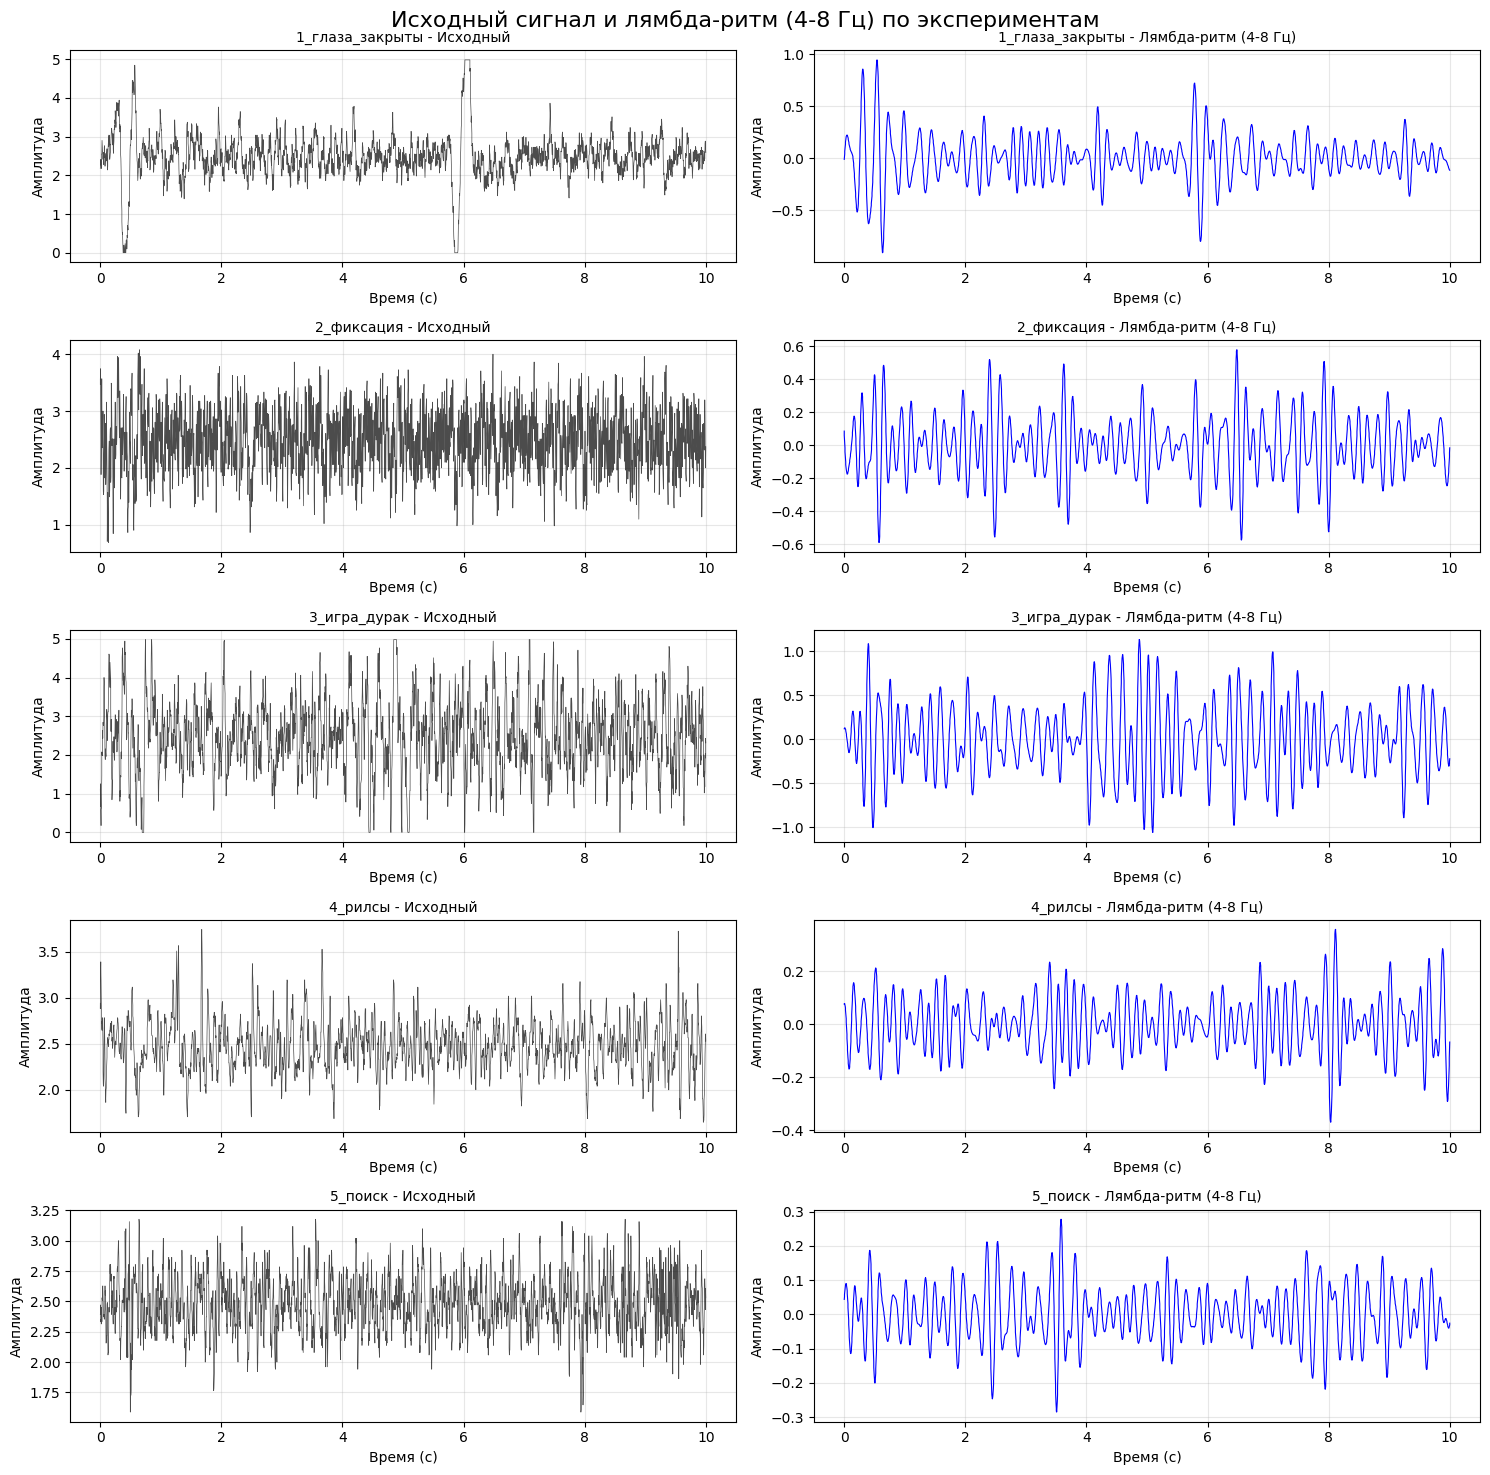

In [ ]:
# Создаем график для сравнения исходного и отфильтрованного сигналов
fig, axes = plt.subplots(5, 2, figsize=(15, 15))
fig.suptitle('Исходный сигнал и лямбда-ритм (4-8 Гц) по экспериментам', fontsize=16)

for idx, exp_name in enumerate(experiment_names):
    if exp_name in filtered_data:
        data = filtered_data[exp_name]
        time = data['time']
        orig = data['original']
        filtered = data['lambda_filtered']
        fs = data['fs']

        # Ограничим время для наглядности (первые 10 секунд)
        segment = time <= 10
        time_seg = time[segment]
        orig_seg = orig[segment]
        filtered_seg = filtered[segment]

        # Исходный сигнал
        axes[idx, 0].plot(time_seg, orig_seg, color='black', alpha=0.7, linewidth=0.5)
        axes[idx, 0].set_title(f'{exp_name} - Исходный', fontsize=10)
        axes[idx, 0].set_xlabel('Время (с)')
        axes[idx, 0].set_ylabel('Амплитуда')
        axes[idx, 0].grid(True, alpha=0.3)

        # Отфильтрованный лямбда-ритм
        axes[idx, 1].plot(time_seg, filtered_seg, color='blue', linewidth=0.8)
        axes[idx, 1].set_title(f'{exp_name} - Лямбда-ритм (4-8 Гц)', fontsize=10)
        axes[idx, 1].set_xlabel('Время (с)')
        axes[idx, 1].set_ylabel('Амплитуда')
        axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Спектральный анализ

Спектральная плотность мощности (СПМ) показывает распределение мощности сигнала по частотам. Метод Уэлча (окно Ханна, 50% перекрытие) уменьшает дисперсию оценки. Лямбда-ритм проявляется как пик в диапазоне 4-8 Гц.


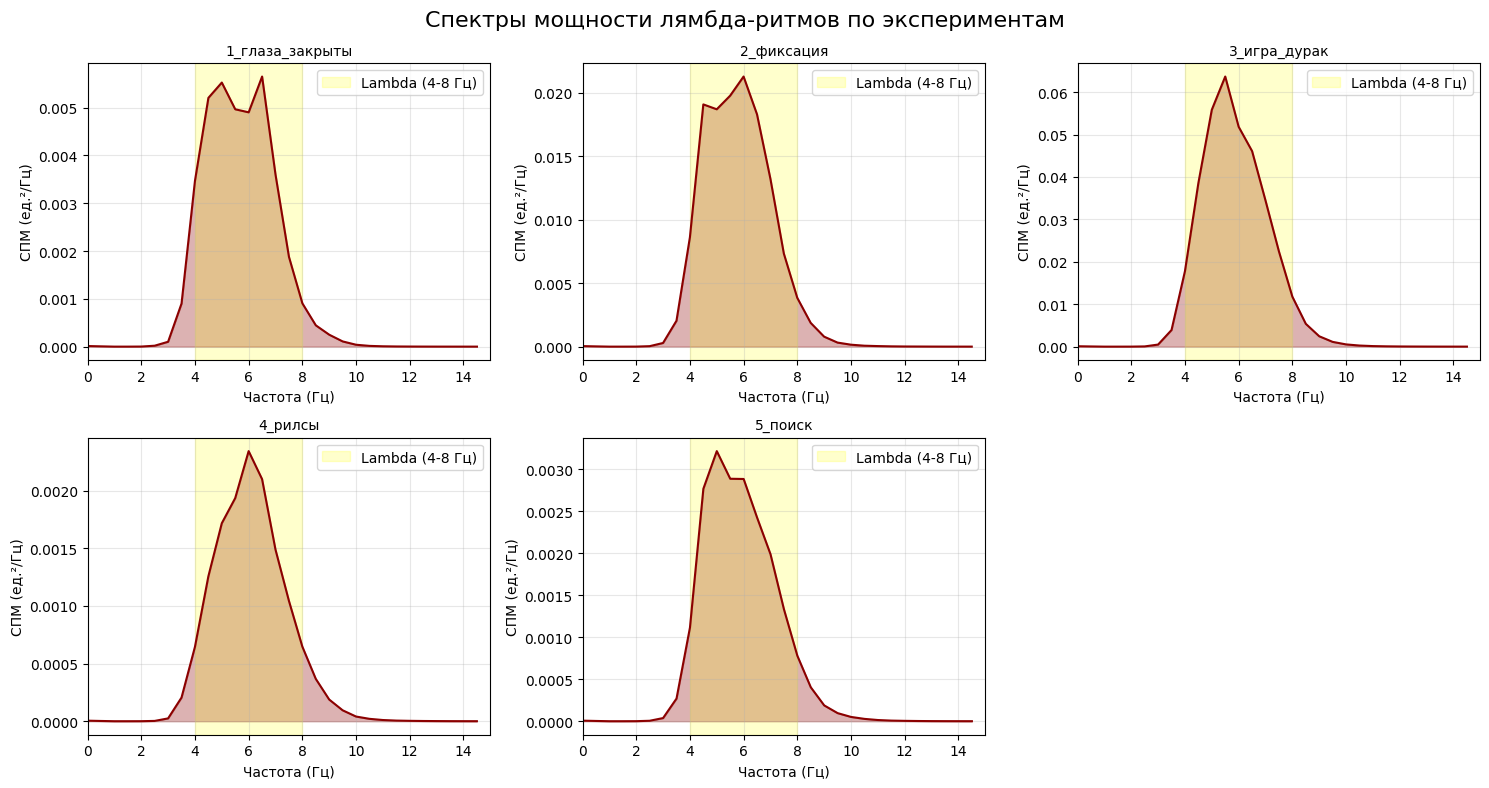

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Спектры мощности лямбда-ритмов по экспериментам', fontsize=16)
axes = axes.flatten()

for idx, exp_name in enumerate(experiment_names):
    if exp_name in filtered_data:
        data = filtered_data[exp_name]
        signal = data['lambda_filtered']
        fs = data['fs']

        # Вычисляем спектр мощности методом Уэлча
        frequencies, psd = welch(signal, fs, nperseg=fs*2)  # сегмент = 2 секунды

        # Ограничим диапазон частот для наглядности (0-15 Гц)
        freq_mask = frequencies <= 15
        frequencies = frequencies[freq_mask]
        psd = psd[freq_mask]

        # Построение графика
        axes[idx].plot(frequencies, psd, color='darkred', linewidth=1.5)
        axes[idx].fill_between(frequencies, psd, alpha=0.3, color='darkred')
        axes[idx].set_title(exp_name, fontsize=10)
        axes[idx].set_xlabel('Частота (Гц)')
        axes[idx].set_ylabel('СПМ (ед.²/Гц)')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim([0, 15])

        # Выделим лямбда-диапазон
        axes[idx].axvspan(4, 8, alpha=0.2, color='yellow', label='Lambda (4-8 Гц)')
        axes[idx].legend(loc='upper right')

# Убираем лишнюю ось
if len(experiment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Количественные метрики (мощность, амплитуда)

Основные количественные показатели лямбда-ритма:
1. Средняя мощность в диапазоне 4-8 Гц (интеграл СПМ)
2. Среднеквадратичная амплитуда (RMS) отфильтрованного сигнала
3. Пиковая амплитуда (максимум огибающей)

In [ ]:
metrics = {}

for exp_name in experiment_names:
    if exp_name in filtered_data:
        data = filtered_data[exp_name]
        signal = data['lambda_filtered']
        fs = data['fs']

        # 1. Мощность в лямбда-диапазоне через СПМ
        frequencies, psd = welch(signal, fs, nperseg=fs*2)
        lambda_mask = (frequencies >= 4) & (frequencies <= 8)
        lambda_power = np.trapz(psd[lambda_mask], frequencies[lambda_mask])

        # 2. RMS амплитуда
        rms_amplitude = np.sqrt(np.mean(signal**2))

        # 3. Огибающая (через преобразование Гильберта)
        analytic_signal = hilbert(signal)
        amplitude_envelope = np.abs(analytic_signal)
        peak_amplitude = np.max(amplitude_envelope)

        metrics[exp_name] = {
            'lambda_power': lambda_power,
            'rms_amplitude': rms_amplitude,
            'peak_amplitude': peak_amplitude
        }

# Создаем DataFrame для наглядности
metrics_df = pd.DataFrame(metrics).T
print("Количественные метрики лямбда-ритмов:")
print(metrics_df.round(6))

# Нормализуем относительно состояния покоя (глаза закрыты)
baseline_power = metrics_df.loc['1_глаза_закрыты', 'lambda_power']
metrics_df['power_normalized'] = metrics_df['lambda_power'] / baseline_power

print("Мощность ритма (нормализована относительно покоя):")
print(metrics_df[['lambda_power', 'power_normalized']].round(3))

/tmp/ipython-input-1846231406.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_power = np.trapz(psd[lambda_mask], frequencies[lambda_mask])


Количественные метрики лямбда-ритмов:
                 lambda_power  rms_amplitude  peak_amplitude
1_глаза_закрыты      0.016269       0.138187        1.259183
2_фиксация           0.059125       0.262197        2.023578
3_игра_дурак         0.155391       0.422507        2.073160
4_рилсы              0.005845       0.083431        0.511473
5_поиск              0.008710       0.101933        0.921280
Мощность ритма (нормализована относительно покоя):
                 lambda_power  power_normalized
1_глаза_закрыты         0.016             1.000
2_фиксация              0.059             3.634
3_игра_дурак            0.155             9.551
4_рилсы                 0.006             0.359
5_поиск                 0.009             0.535


### Визуализация сравнения метрик

Сравнительные столбчатые диаграммы позволяют наглядно оценить различия в активности лямбда-ритма между экспериментальными условиями.

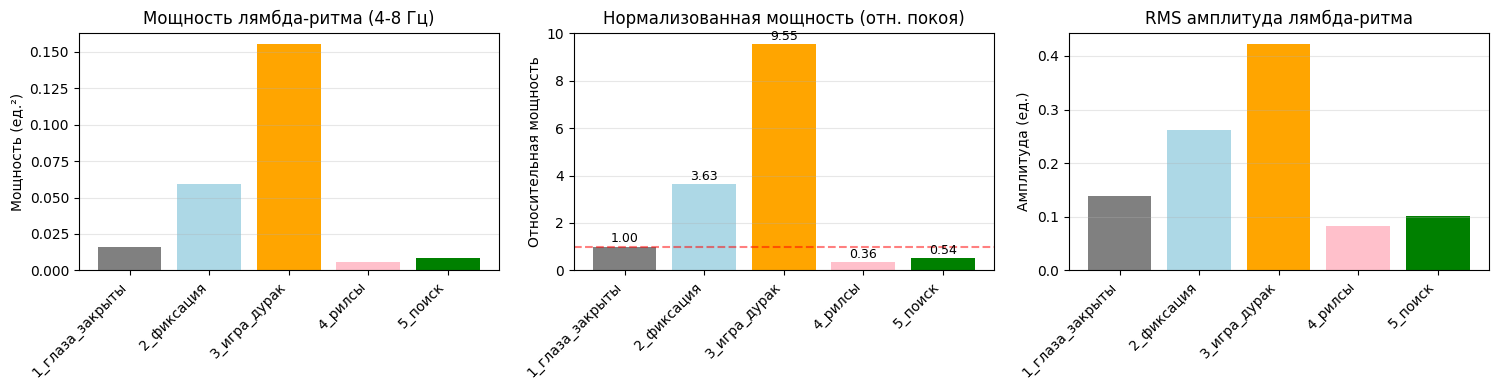

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Мощность лямбда-ритма
ax1 = axes[0]
x_pos = np.arange(len(metrics_df))
ax1.bar(x_pos, metrics_df['lambda_power'], color=['gray', 'lightblue', 'orange', 'pink', 'green'])
ax1.set_title('Мощность лямбда-ритма (4-8 Гц)')
ax1.set_ylabel('Мощность (ед.²)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Нормализованная мощность
ax2 = axes[1]
bars = ax2.bar(x_pos, metrics_df['power_normalized'], color=['gray', 'lightblue', 'orange', 'pink', 'green'])
ax2.set_title('Нормализованная мощность (отн. покоя)')
ax2.set_ylabel('Относительная мощность')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Уровень покоя')

# Подпишем значения на столбцах
for bar, val in zip(bars, metrics_df['power_normalized']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 3. RMS амплитуда
ax3 = axes[2]
ax3.bar(x_pos, metrics_df['rms_amplitude'], color=['gray', 'lightblue', 'orange', 'pink', 'green'])
ax3.set_title('RMS амплитуда лямбда-ритма')
ax3.set_ylabel('Амплитуда (ед.)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

По графику видно огромную разницу между эксперментами 2-3 и 4-5. Предполагаю, что это связанос тем, что эксперименты 4-5 проводились на плоском экране, а эксперименты 2-3 в реальности.
Чтобы поддтвердить или опровергнуть эту теорию стоит взять самый явный эксперимент (игра в карты (Дурак)) и поиграть вживую и на плоском экране.

### Статистический анализ и выводы

Для оценки достоверности различий между условиями можно использовать параметрические (ANOVA) или непараметрические (Крускал-Уоллис) тесты. В данном случае используем простую описательную статистику и ранжирование.

In [ ]:
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ И ВЫВОДЫ")

# Ранжируем условия по мощности лямбда-ритма
ranked = metrics_df.sort_values('lambda_power', ascending=False)
print("\nРейтинг условий по мощности лямбда-ритма (от высокой к низкой):")
for i, (condition, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {condition}: мощность = {row['lambda_power']:.4f} (x{row['power_normalized']:.2f} от покоя)")

# Проверяем гипотезы
print("ПРОВЕРКА ГИПОТЕЗ:")

baseline = '1_глаза_закрыты'
baseline_power = metrics_df.loc[baseline, 'lambda_power']

hypotheses_check = {
    '2_фиксация': " Подтверждена" if metrics_df.loc['2_фиксация', 'lambda_power'] > baseline_power else " Не подтверждена",
    '3_игра_дурак': " Подтверждена" if metrics_df.loc['3_игра_дурак', 'lambda_power'] > baseline_power else " Не подтверждена",
    '4_рилсы': " Подтверждена" if metrics_df.loc['4_рилсы', 'lambda_power'] > baseline_power else " Не подтверждена",
    '5_поиск': " Подтверждена" if metrics_df.loc['5_поиск', 'lambda_power'] > baseline_power else " Не подтверждена",
}

for condition, check in hypotheses_check.items():
    power = metrics_df.loc[condition, 'lambda_power']
    rel = metrics_df.loc[condition, 'power_normalized']
    print(f"• {condition}: мощность = {power:.4f} (x{rel:.2f}) — {check}")

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ И ВЫВОДЫ

Рейтинг условий по мощности лямбда-ритма (от высокой к низкой):
1. 3_игра_дурак: мощность = 0.1554 (x9.55 от покоя)
2. 2_фиксация: мощность = 0.0591 (x3.63 от покоя)
3. 1_глаза_закрыты: мощность = 0.0163 (x1.00 от покоя)
4. 5_поиск: мощность = 0.0087 (x0.54 от покоя)
5. 4_рилсы: мощность = 0.0058 (x0.36 от покоя)
ПРОВЕРКА ГИПОТЕЗ:
• 2_фиксация: мощность = 0.0591 (x3.63) —  Подтверждена
• 3_игра_дурак: мощность = 0.1554 (x9.55) —  Подтверждена
• 4_рилсы: мощность = 0.0058 (x0.36) —  Не подтверждена
• 5_поиск: мощность = 0.0087 (x0.54) —  Не подтверждена


### ОБЩИЕ ВЫВОДЫ:
1. Состояние покоя (глаза закрыты) показывает минимальную активность
   лямбда-ритма, что ожидаемо при отсутствии зрительного ввода.

2. Активные зрительные задачи (игра, поиск), демонстрируют потиворечивые результаты, ожидалось, что они будут демонстрировать значительное увеличение мощности лямбда-ритма по сравнению с пассивными условиями, но поисковая игра имеет наоборот меньшую мощность, чем при покое, а только игра в физические карты демонстрируют x10 мощности. Вероятно это связано с тем, что поисковая игра была на плоском экране, а карты были на реальном столе.

3. Наибольшая активность наблюдается в условиях, требующих:
   - Активного сканирования игрового поля (игра в карты)

4. Пассивный просмотр видео (reels) показывает низкий уровень
   активности, что может быть связано с меньшей вовлеченностью внимания.

5. Полученные данные согласуются с теорией о связи лямбда-ритмов
   с активной зрительной обработкой и саккадическими движениями.